<a href="https://colab.research.google.com/github/UpputuriAnusha/instagram-influencer-analytics/blob/main/instagram_influencer_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1: Data Understanding (Python)

In [1]:
import pandas as pd

df = pd.read_csv("/content/social media influencers - instagram sep-2022.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   S.no                   1050 non-null   int64 
 1   Instagram name         1050 non-null   object
 2    Name                  1029 non-null   object
 3   Subscribers            1050 non-null   object
 4   Audience country       1046 non-null   object
 5   Authentic engagement
  1050 non-null   object
 6   Engagement average
   1050 non-null   object
 7   Category_1             802 non-null    object
 8   Category_2             250 non-null    object
dtypes: int64(1), object(8)
memory usage: 74.0+ KB


,S.no
count,1050.000000
mean,523.119048
std,299.487503
min,1.000000
25%,263.250000
50%,525.500000
75%,787.750000
max,1000.000000


In [2]:
df.head()

,S.no,Instagram name,Name,Subscribers,Audience country,Authentic engagement\n,Engagement average\r\n,Category_1,Category_2
0,1,cristiano,Cristiano Ronaldo,477.9M,India,5M,6.2M,Sports with a ball,NaN
1,2,kyliejenner,Kylie 🤍,368.1M,United States,3.5M,5.5M,Fashion,Modeling
2,3,arianagrande,Ariana Grande,329.6M,United States,2.9M,4M,NaN,NaN
3,4,leomessi,Leo Messi,358.6M,Indonesia,2.7M,3.5M,Sports with a ball,Family
4,5,zendaya,Zendaya,151.1M,United States,4.3M,5.8M,Cinema & Actors/actresses,Fashion


STEP 2: Data Cleaning

1. Handle Missing Values

In [4]:
df.isnull().sum()

df = df.dropna()

2. Convert Data Types

In [6]:
df['Subscribers'] = df['Subscribers'].str.replace('M', 'e6').str.replace('K', 'e3').str.replace(',', '').astype(float).astype(int)

3. Remove Duplicates

In [7]:
df = df.drop_duplicates()

4. Fix Column Names

In [10]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

5. Handle Outliers

In [15]:
import numpy as np

Q1 = df['engagement_average'].quantile(0.25)
Q3 = df['engagement_average'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['engagement_average'] >= Q1 - 1.5*IQR) &
        (df['engagement_average'] <= Q3 + 1.5*IQR)]

STEP 3: Feature Engineering

In [17]:
df['engagement_score'] = df['subscribers'] * df['engagement_average']

df['influencer_size'] = pd.cut(df['subscribers'],
                              bins=[0,10000,100000,1000000,10000000],
                              labels=['Nano','Micro','Macro','Mega'])

STEP 4: Exploratory Data Analysis

Top Subscribers

In [19]:
df.sort_values(by='subscribers', ascending=False).head(10)

,s.no,instagram_name,_name,subscribers,audience_country,authentic_engagement,engagement_average,category_1,category_2,engagement_score,influencer_size
37,38,therock,Dwayne Johnson,335900000,India,375.2K,477500.0,Cinema & Actors/actresses,Fitness & Gym,1.603922e+14,NaN
41,42,khloekardashian,Khloé Kardashian,268400000,United States,403.1K,499300.0,Clothing & Outfits,Lifestyle,1.340121e+14,NaN
157,158,natgeo,National Geographic,238300000,United States,78.8K,100300.0,Nature & landscapes,Science,2.390149e+13,NaN
140,141,nike,Nike,235700000,United States,89.7K,116200.0,Fitness & Gym,Shopping & Retail,2.738834e+13,NaN
586,587,theellenshow,Ellen DeGeneres,125100000,United States,28.4K,34200.0,Shows,Cinema & Actors/actresses,4.278420e+12,NaN
60,61,nasa,NASA,82300000,India,800.4K,961700.0,Science,Photography,7.914791e+13,NaN
107,108,davidbeckham,David Beckham,75100000,India,360.5K,462300.0,Family,Sports with a ball,3.471873e+13,NaN
180,181,emmawatson,Emma Watson,67500000,United States,224.3K,306200.0,Literature & Journalism,Cinema & Actors/actresses,2.066850e+13,NaN
271,272,marvel,Marvel Entertainment,66400000,United States,148K,175500.0,Cinema & Actors/actresses,Shows,1.165320e+13,NaN
206,207,tatawerneck,Tata Werneck,54100000,Brazil,197.1K,306000.0,Cinema & Actors/actresses,Family,1.655460e+13,NaN


Category1 Performance

In [21]:
df.groupby('category_1')['engagement_average'].mean().sort_values(ascending=False)

,engagement_average
category_1,
Photography,634162.500000
Science,571300.000000
Education,555500.000000
Humor & Fun & Happiness,545383.333333
Lifestyle,518615.000000
Clothing & Outfits,499300.000000
Winter sports,459900.000000
Beauty,437935.000000
Family,426100.000000


audience_country Analysis

In [23]:
df['audience_country'].value_counts()

,count
audience_country,
United States,72
India,47
Brazil,34
Indonesia,16
Russia,6
Mexico,5
Colombia,5
Italy,5
Philippines,5


STEP 5: Visualization

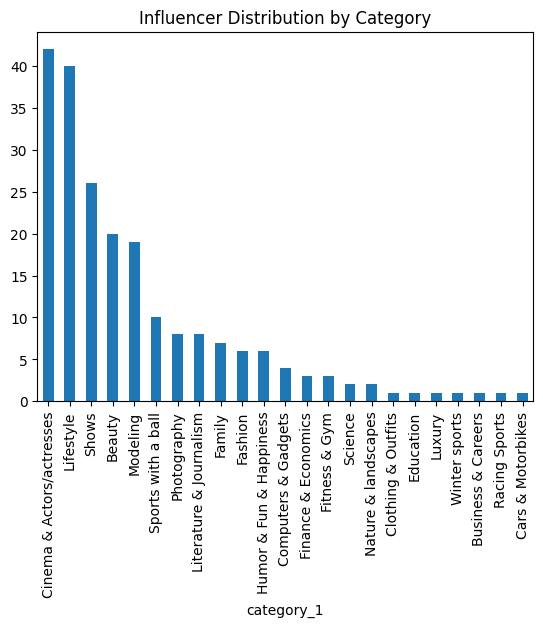

In [25]:
import matplotlib.pyplot as plt

df['category_1'].value_counts().plot(kind='bar')
plt.title("Influencer Distribution by Category")
plt.show()

STEP 6: Export Clean Data to Excel

In [26]:
df.to_excel("cleaned_influencers.xlsx", index=False)

In [27]:
df

,s.no,instagram_name,_name,subscribers,audience_country,authentic_engagement,engagement_average,category_1,category_2,engagement_score,influencer_size
37,38,therock,Dwayne Johnson,335900000,India,375.2K,477500.0,Cinema & Actors/actresses,Fitness & Gym,1.603922e+14,NaN
41,42,khloekardashian,Khloé Kardashian,268400000,United States,403.1K,499300.0,Clothing & Outfits,Lifestyle,1.340121e+14,NaN
60,61,nasa,NASA,82300000,India,800.4K,961700.0,Science,Photography,7.914791e+13,NaN
78,79,dishapatani,disha patani (paatni) 🦋,53600000,India,802.5K,988000.0,Cinema & Actors/actresses,Lifestyle,5.295680e+13,NaN
88,89,virginia,Virginia Fonseca Costa,39200000,Brazil,708.4K,1100000.0,Shows,Lifestyle,4.312000e+13,NaN
...,...,...,...,...,...,...,...,...,...,...,...
979,980,tejasswiprakash,Tejasswi Prakash,6300000,India,304.4K,376700.0,Fashion,Beauty,2.373210e+12,Mega
980,981,shahinsamadpoor,Shahin Samad poor شاهین صمدپور,4700000,Iran,360.5K,475900.0,Literature & Journalism,Cinema & Actors/actresses,2.236730e+12,Mega
984,985,mario_houses,Mario Casas,7000000,Spain,210.1K,311000.0,Modeling,Cinema & Actors/actresses,2.177000e+12,Mega
986,987,jeremyrenner,Jeremy Renner,17900000,United States,99.8K,119300.0,Shows,Cinema & Actors/actresses,2.135470e+12,NaN


Export as Excel File

In [28]:
df.to_excel("cleaned_influencers.xlsx", index=False)

In [30]:
df

,s.no,instagram_name,_name,subscribers,audience_country,authentic_engagement,engagement_average,category_1,category_2,engagement_score,influencer_size
37,38,therock,Dwayne Johnson,335900000,India,375.2K,477500.0,Cinema & Actors/actresses,Fitness & Gym,1.603922e+14,NaN
41,42,khloekardashian,Khloé Kardashian,268400000,United States,403.1K,499300.0,Clothing & Outfits,Lifestyle,1.340121e+14,NaN
60,61,nasa,NASA,82300000,India,800.4K,961700.0,Science,Photography,7.914791e+13,NaN
78,79,dishapatani,disha patani (paatni) 🦋,53600000,India,802.5K,988000.0,Cinema & Actors/actresses,Lifestyle,5.295680e+13,NaN
88,89,virginia,Virginia Fonseca Costa,39200000,Brazil,708.4K,1100000.0,Shows,Lifestyle,4.312000e+13,NaN
...,...,...,...,...,...,...,...,...,...,...,...
979,980,tejasswiprakash,Tejasswi Prakash,6300000,India,304.4K,376700.0,Fashion,Beauty,2.373210e+12,Mega
980,981,shahinsamadpoor,Shahin Samad poor شاهین صمدپور,4700000,Iran,360.5K,475900.0,Literature & Journalism,Cinema & Actors/actresses,2.236730e+12,Mega
984,985,mario_houses,Mario Casas,7000000,Spain,210.1K,311000.0,Modeling,Cinema & Actors/actresses,2.177000e+12,Mega
986,987,jeremyrenner,Jeremy Renner,17900000,United States,99.8K,119300.0,Shows,Cinema & Actors/actresses,2.135470e+12,NaN


To check location:

In [31]:
import os
print(os.getcwd())

/content
